In [13]:
# In this notebook, we are going to implement the web search part of CRAG architecture.
# So, if the retrieved chunks are classified as "INCORRECT", then we will use the web search part.
# But if the retrieved chunks are classified as "AMBIGUOUS", then we won't do anything. This case will be handled in the next notebook.

In [46]:
from typing import List, TypedDict, Annotated
from pydantic import BaseModel, Field
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
docs = (
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day25_Corrective_RAG\books\book1.pdf").load() + 
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day25_Corrective_RAG\books\book2.pdf").load() + 
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day25_Corrective_RAG\books\book3.pdf").load()
)

In [5]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 900, chunk_overlap = 150)

chunks = splitter.split_documents(docs)

In [6]:
# Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [7]:
embedding_model = OpenAIEmbeddings(model = "text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embedding = embedding_model)

In [8]:
retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs = {"k": 4})

In [9]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

In [10]:
# upper threshold
UPPER_TH = 0.7

# lower threshold
LOWER_TH = 0.3

In [11]:
class State(TypedDict):
    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_docs: List[Document]
    web_query: str

    answer: str

In [12]:
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [ ]:
class DocEvalScore(BaseModel):
    score: Annotated[float, Field(ge = 0.0, le = 1.0)]
    reason: Annotated[str, Field(description = "reason for the assigned score in one sentence")]


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only."
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}")
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)
# Again, researchers fine-tuned the google t-5 large LLM for this document evaluation task which is lighter and better than GPT and other SOTA models for this task.
# But we have to use GPT chat model because the researchers haven't made the fine-tuned evaluator public yet.

def eval_each_doc_node(state: State):
    q = state['question']

    scores: List[float] = []
    reasons: List[str] = []
    good_docs: List[Document] = []  # We will add all those documents to 'good_docs' which have score greater than lower threshold i.e., 0.3

    for doc in state['docs']:
        eval_output: DocEvalScore = doc_eval_chain.invoke({"question": q, "chunk": doc.page_content})
        scores.append(eval_output.score)
        reasons.append(eval_output.reason)

        if eval_output.score > LOWER_TH:
            good_docs.append(doc)
    

    # CORRECT if at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good_docs,
            "verdict": "CORRECT",
            "reason": f"Atleast one retrieved chunk scored > {UPPER_TH}"
        }

    # INCORRECT if all docs < LOWER_TH
    if all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}"
        }
    
    # Anything in between => AMBIGUOUS
    why = "Mixed relevance signals"
    return {
        "good_docs": good_docs,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}"
    }


In [37]:
# Sentence-level DECOMPOSER
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only."
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}")
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state: State):
    q = state['question']
    
    if state.get("verdict") == "CORRECT":
        context = "\n\n".join(d.page_content for d in state['good_docs']).strip()
    else:
        context = "\n\n".join(d.page_content for d in state['web_docs']).strip()
    strips = decompose_to_sentences(context)

    kept_strips: List[str] = []

    for strip in strips:
        if filter_chain.invoke({"question": q, "sentence": strip}).keep:
            kept_strips.append(strip)
    
    refined_context = "\n".join(kept_strips).strip()

    return {
        "strips": strips,
        "kept_strips": kept_strips,
        "refined_context": refined_context
    }


In [38]:
# Now, before web search, the researchers suggested to rewrite the user's query for better coverage in web search. Not always useful, but works many times.

class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6-14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),

        ("human", "Question: {question}")
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

In [39]:
# Web search node -> uses web_query
tavily = TavilySearchResults(max_results = 5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    web_docs: List[Document] = []

    for r in results:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content = text, metadata = {"url": url, "title": title}))
    
    return {"web_docs": web_docs}


In [40]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'"
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}")
    ]
)

def generate(state: State):
    out = (answer_prompt | llm).invoke(
        {"question": state["question"], "refined_context": state["refined_context"]}
    )
    return {"answer": out.content}

In [41]:
def ambiguous_node(state: State):
    return {
        "answer": f"Ambiguous: {state['reason']}"
    }

def route_after_eval(state: State):
    if state['verdict'] == "CORRECT":
        return "refine"
    elif state['verdict'] == "INCORRECT":
        return "rewrite_query"
    else:
        return "ambiguous"

In [42]:
graph = StateGraph(State)

graph.add_node("retrieve", retrieve_node)
graph.add_node("eval_each_doc", eval_each_doc_node)
graph.add_node("rewrite_query", rewrite_query_node)
graph.add_node("web_search", web_search_node)
graph.add_node("refine", refine)
graph.add_node("generate", generate)
graph.add_node("ambiguous", ambiguous_node)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "eval_each_doc")
graph.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {"refine": "refine", "rewrite_query": "rewrite_query", "ambiguous": "ambiguous"}
)
graph.add_edge("rewrite_query", "web_search")
graph.add_edge("web_search", "refine")  # This is very important. Researchers suggested to always refine the web search results in the exact manner in which we refine the retrieved docs by the retriever.
graph.add_edge("refine", "generate")
graph.add_edge("generate", END)
graph.add_edge("ambiguous", END)

workflow = graph.compile()

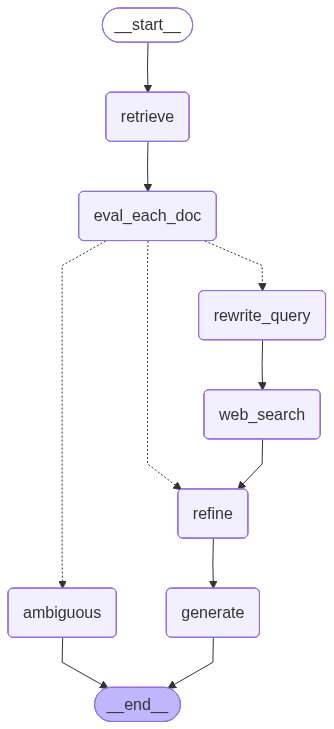

In [43]:
workflow

In [44]:
res = workflow.invoke(
    {
        "question": "Recent AI news",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],
        "answer": ""
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3

OUTPUT:
 Between January 10 and 17, 2026, the AI industry reached a significant turning point, evolving from an "interactive tool" to a "physical entity" with the potential to transform various industries, particularly manufacturing. Notable developments included the announcement by Chinese AI startup DeepSeek of its next-generation AI model, V4, which specializes in coding and has outperformed existing models in tests. Additionally, the UK government announced a £36m upgrade for the Dawn supercomputer to enhance its capabilities for public projects. Other news included the rise of AI in various sectors, such as Airbnb integrating AI into customer support and the ongoing debates around AI-generated content in Hollywood.


In [45]:
res

{'question': 'Recent AI news',
 'docs': [Document(id='60450989-cd96-41bf-a63e-9ade2d3c605a', metadata={'producer': 'Antenna House PDF Output Library 6.2.609 (Linux64)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2017-03-10T21:55:34+00:00', 'author': 'Aurélien Géron', 'moddate': '2017-07-29T21:43:02+08:00', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow', 'trapped': '/False', 'source': 'C:\\Users\\Administrator\\Desktop\\LangGraph Exploration\\Day25_Corrective_RAG\\books\\book3.pdf', 'total_pages': 564, 'page': 458, 'page_label': '437'}, page_content='Backgammon playing program) and in machine control, but seldom making the\nheadline news. But a revolution took place in 2013 when researchers from an English\nstartup called DeepMind demonstrated a system that could learn to play just about\nany Atari game from scratch, 2 eventually outperforming humans 3 in most of them,\nusing only raw pixels as inputs a